In [1]:
import numpy as np
from ait.photonic_testing.photonic_testing import *
MODBUS_PORT='/dev/tty.usbserial-B003T6PZ'
# MODBUS_PORT='/dev/tty.usbserial-B003T6RF'
LASER_ADDRESSES = {"1028": 5,
                   "1270": 6,
                   "yj1430": 4,
                   "hk1430": 3,
                   "1510": 1,
                   "2330": 2}

LASER_DRIVER_SERIALS = {"1028": 8229,
                   "1270": 8228,
                   "yj1430": 8222,
                   "hk1430": 8227,
                   "1510": 8225,
                   "2330": 8226}

## Overview

1. [Code Primer](#Code-Primer)
2. [Test Control](#Static-Attenuators)
3. [Result Data](#Measurements)
4. [Analysis](#Analysis)

## Code Primer


See `ait/photonic_testing/photonic_testing.py` for `Laser` and `LaserProperties` along with the specific limits of the individual laser diodes.

#### Low-level access

In the event that direct device control is needed.

See `ait/photonic_testing/maiman_modbus/utils/utils.py` for python constants of register names and `ait/photonic_testing/maiman_modbus/config/modbus_config.yaml` for the register addresses.

Look at methods on `ModbusDevice` (`ait/maiman_modbus/device/modbus_device.py`) for functions.


```python
from maiman_modbus.communication import ModbusCommunication
import maiman_modbus.utils as maiman_regs
from maiman_modbus.device.modbus_device_model import ModbusDeviceModel
from maiman_modbus.config import DeviceConfig
from maiman_modbus.device.modbus_device import ModbusDevice

d = ModbusDevice(port=MODBUS_PORT, slave_address=modbus_address)
d.comm.send_command(d.model.get_register(STATE_OF_TEC_COMMAND), MODBUS_START_TEC_COMMAND_VALUE)

print(d.comm.receive_response(d.model.get_register(STATE_OF_TEC_COMMAND)))
```


## Initialize all the diodes

Running this cell will create the `lasers` dictionary with a `Laser` for each laser.

In [2]:
names = tuple(LASER_ADDRESSES.keys())
lasers = {}
for name in names:
    l = Laser(name, address=LASER_ADDRESSES[name], MODBUS_PORT=MODBUS_PORT)
    serial = l.device.get_serial_number()
    print(f'🆔 Serial number: {serial}')
    assert l.device.get_serial_number()==LASER_DRIVER_SERIALS[name], 'BAD BUS CONFIG, do not continue'
    lasers[name] = l
    print('')


for name in names:
    serial = lasers[name].device.get_serial_number()
    assert serial==LASER_DRIVER_SERIALS[name], 'BAD BUS CONFIG, do not continue'



Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
🆔 Serial number: 8229

Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
🆔 Serial number: 8228

Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
🆔 Serial number: 8222

Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
🆔 Serial number: 8227

Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
🆔 Serial number: 8225

Raw ID from register: 0x1113
🆔 Found device ID: 4371
📦 Loaded device configuration.
🆔 Serial number: 8226



### Start the TECs

In [ ]:
for name in names:
    lasers[name].disable_interlock_and_cool()

## Test Control
This sets a percentage between the maximum current and the threshold current.

In [ ]:
# Play with this cell as needed to gather data
lasers['1028'].set_current_as_percent(.5)

#### Make sure all the diodes and TECs are off when we are all done...

In [6]:
for name in names:
    lasers[name].shutdown()

## Measurements

#### Static Attenuator Notes:
- APC/PC Converter was used, may cause additional loss.
- FTO patchcable (REF cable) used at attenuator output for YJ, LVF for HK.

In [ ]:
from dataclasses import make_dataclass
import pandas as pd
import matplotlib.pyplot as plt
Measurement = make_dataclass("Measurement", [("laser", str), ("current", float), ("power", float), ('dut', str), ("comment", str)])

### Laser Spectra

#### 1028
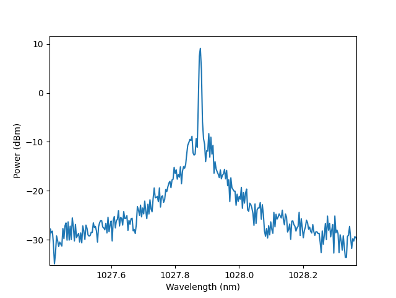

#### 1270
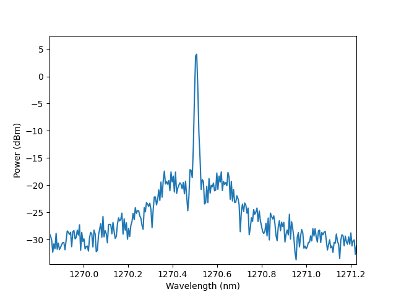

#### yj1430
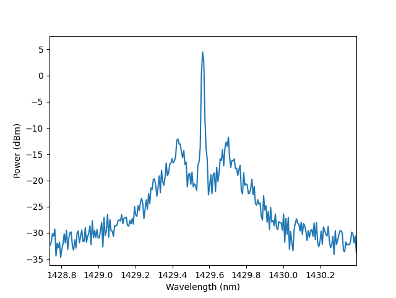


#### Laser Powers

In [3]:
laser_powers = pd.DataFrame([
    #1028 LD powers
    Measurement('1028', 37.6, 4, 'diode', ''),
    Measurement('1028', 83.7, 12.04, 'diode', ''),
    Measurement('1028', 129.8, 20.44, 'diode', ''),
    Measurement('1028', 175.9, 29.02, 'diode', ''),
    Measurement('1028', 221.9, 36.96, 'diode', ''),

    #1270 LD powers
    Measurement('1270', 13.7, 0.771, 'diode', ''),
    Measurement('1270', 25.1, 3.17, 'diode', ''),
    Measurement('1270', 36.5, 5.65, 'diode', ''),
    Measurement('1270', 47.9, 8.16, 'diode', ''),
    Measurement('1270', 59.3, 10.59, 'diode', ''),

    # yj1430 LD powers
    Measurement('yj1430', 13.7, 2.0, 'diode', ''),
    Measurement('yj1430', 25.1, 4.4, 'diode', ''),
    Measurement('yj1430', 36.5, 6.83, 'diode',''),
    Measurement('yj1430', 47.9, 9.1, 'diode', ''),
    Measurement('yj1430', 59.3, 11.5, 'diode',''),

    # hk1430 LD powers
    Measurement('hk1430', 13.7, 2.3, 'diode', ''),
    Measurement('hk1430', 25.1, 5.0, 'diode', ''),
    Measurement('hk1430', 36.5, 7.8, 'diode', ''),
    Measurement('hk1430', 47.9, 10.5, 'diode', ''),
    Measurement('hk1430', 59.3, 13.0, 'diode', ''),

    # 1510 LD powers
    Measurement('1510', 13.7, 2.55, 'diode', ''),
    Measurement('1510', 25.1, 5.43, 'diode', ''),
    Measurement('1510', 36.5, 8.34, 'diode', ''),
    Measurement('1510', 47.9, 11.15, 'diode', ''),
    Measurement('1510', 59.3, 14.0, 'diode', ''),

    # 2330 LD powers
    Measurement('2330', 33.9, 0.372, 'diode', ''),
    Measurement('2330', 51.9, 0.835, 'diode', ''),
    Measurement('2330', 69.9, 1.31, 'diode', ''),
    Measurement('2330', 87.9, 1.76, 'diode', ''),
])

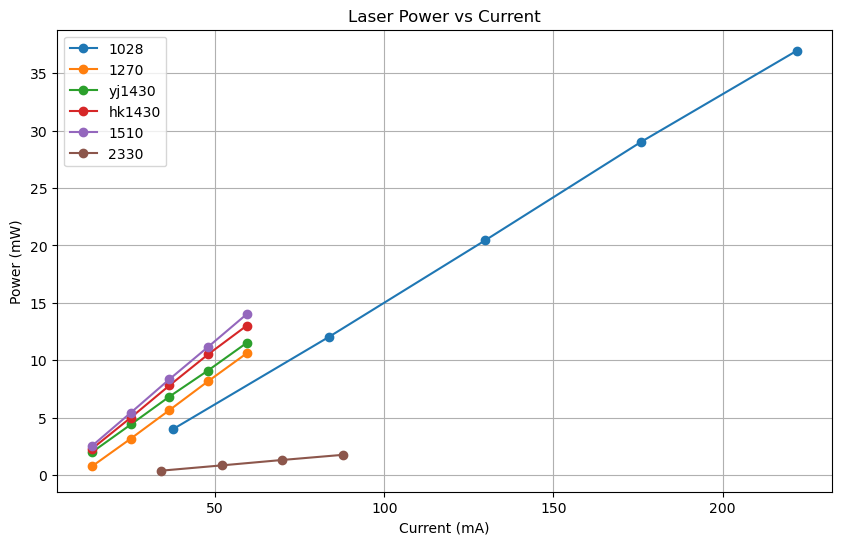

In [4]:
plt.figure(figsize=(10, 6))
for laser in laser_powers['laser'].unique():
    laser_data = laser_powers[laser_powers['laser'] == laser]
    plt.plot(laser_data['current'], laser_data['power'], 'o-', label=laser)

plt.xlabel('Current (mA)')
plt.ylabel('Power (mW)')
plt.title('Laser Power vs Current')
plt.legend()
plt.grid(True)
plt.show()


#### Static Attenuator Performance

In [10]:
attenuation_df = pd.DataFrame([
    # 1028nm measurements
    Measurement('1028', 20.44, 14.59, 'PC/APC', ''),
    Measurement('1028', 20.44, 14.84, 'PC/APC', ''),
    Measurement('1028', 20.44, 14.74, 'PC/APC', ''),

    Measurement('1028', 20.44, 9.76, 'PC/APC+3dB', ''),
    Measurement('1028', 20.44, 9.91, 'PC/APC+3dB', ''),
    Measurement('1028', 20.44, 10.05, 'PC/APC+3dB', ''),

    Measurement('1028', 20.44, 6.60, 'PC/APC+5dB', ''),
    Measurement('1028', 20.44, 6.70, 'PC/APC+5dB', ''),
    Measurement('1028', 20.44, 6.79, 'PC/APC+5dB', ''),

    Measurement('1028', 20.44, 4.17, 'PC/APC+10dB', ''),
    Measurement('1028', 20.44, 4.02, 'PC/APC+10dB', ''),
    Measurement('1028', 20.44, 4.03, 'PC/APC+10dB', ''),

    Measurement('1028', 20.44, .801, 'PC/APC+20dB', ''),
    Measurement('1028', 20.44, .719, 'PC/APC+20dB', ''),
    Measurement('1028', 20.44, .870, 'PC/APC+20dB', ''),

    Measurement('1028', 20.44, .169, 'PC/APC+25dB', ''),
    Measurement('1028', 20.44, .198, 'PC/APC+25dB', ''),
    Measurement('1028', 20.44, .172, 'PC/APC+25dB', ''),

    # 1270nm measurements
    Measurement('1270', 5.65, 4.916, 'PC/APC', ''),
    Measurement('1270', 5.65, 2.530, 'PC/APC+3dB', ''),
    Measurement('1270', 5.65, 1.520, 'PC/APC+5dB', ''),
    Measurement('1270', 5.65, 0.475, 'PC/APC+10dB', ''),
    Measurement('1270', 5.65, 0.0443, 'PC/APC+20dB', ''),
    Measurement('1270', 5.65, 0.00585, 'PC/APC+25dB', ''),

    Measurement('1270', 5.65, 5.032, 'PC/APC', ''),
    Measurement('1270', 5.65, 2.327, 'PC/APC+3dB', ''),
    Measurement('1270', 5.65, 1.448, 'PC/APC+5dB', ''),
    Measurement('1270', 5.65, 0.497, 'PC/APC+10dB', ''),
    Measurement('1270', 5.65, 0.0455, 'PC/APC+20dB', ''),
    Measurement('1270', 5.65, 0.00522, 'PC/APC+25dB', ''),

    Measurement('1270', 5.65, 4.947, 'PC/APC', ''),
    Measurement('1270', 5.65, 2.348, 'PC/APC+3dB', ''),
    Measurement('1270', 5.65, 1.530, 'PC/APC+5dB', ''),
    Measurement('1270', 5.65, 0.522, 'PC/APC+10dB', ''),
    Measurement('1270', 5.65, 0.0478, 'PC/APC+20dB', ''),
    Measurement('1270', 5.65, 0.00607, 'PC/APC+25dB', ''),

    #yj1430
    Measurement('yj1430', 6.83, 6.2, 'PC/APC', ''),
    Measurement('yj1430', 6.83, 3.127, 'PC/APC+3dB', ''),
    Measurement('yj1430', 6.83, 1.863, 'PC/APC+5dB', ''),
    Measurement('yj1430', 6.83, 0.682, 'PC/APC+10dB', ''),
    Measurement('yj1430', 6.83, 0.057, 'PC/APC+20dB', ''),
    Measurement('yj1430', 6.83, 0.01108, 'PC/APC+25dB', ''),

    Measurement('yj1430', 6.83, 6.29, 'PC/APC', ''),
    Measurement('yj1430', 6.83, 3.09300, 'PC/APC+3dB', ''),
    Measurement('yj1430', 6.83, 1.87900, 'PC/APC+5dB', ''),
    Measurement('yj1430', 6.83, 0.71000, 'PC/APC+10dB', ''),
    Measurement('yj1430', 6.83, 0.05510, 'PC/APC+20dB', ''),
    Measurement('yj1430', 6.83, 0.01066, 'PC/APC+25dB', ''),

    Measurement('yj1430', 6.83, 6.22000, 'PC/APC', ''),
    Measurement('yj1430', 6.83, 3.23400, 'PC/APC+3dB', ''),
    Measurement('yj1430', 6.83, 1.87700, 'PC/APC+5dB', ''),
    Measurement('yj1430', 6.83, 0.69800, 'PC/APC+10dB', ''),
    Measurement('yj1430', 6.83, 0.05520, 'PC/APC+20dB', ''),
    Measurement('yj1430', 6.83, 0.01027, 'PC/APC+25dB', ''),

    #hk1430
    Measurement('hk1430', 7.80, 2.67, 'PC/APC', ''),
    Measurement('hk1430', 7.80, 1.33000, 'PC/APC+3dB', ''),
    Measurement('hk1430', 7.80, 1.03000, 'PC/APC+5dB', ''),
    Measurement('hk1430', 7.80, 0.25700, 'PC/APC+10dB', ''),
    Measurement('hk1430', 7.80, 0.00943, 'PC/APC+20dB', ''),
    Measurement('hk1430', 7.80, 0.00177, 'PC/APC+25dB', ''),

    Measurement('hk1430', 7.80, 2.90000, 'PC/APC', ''),
    Measurement('hk1430', 7.80, 1.27000, 'PC/APC+3dB', ''),
    Measurement('hk1430', 7.80, 1.09000, 'PC/APC+5dB', ''),
    Measurement('hk1430', 7.80, 0.24300, 'PC/APC+10dB', ''),
    Measurement('hk1430', 7.80, 0.00923, 'PC/APC+20dB', ''),
    Measurement('hk1430', 7.80, 0.00161, 'PC/APC+25dB', ''),

    Measurement('hk1430', 7.80, 3.0, 'PC/APC', ''),
    Measurement('hk1430', 7.80, 1.30000, 'PC/APC+3dB', ''),
    Measurement('hk1430', 7.80, 1.12000, 'PC/APC+5dB', ''),
    Measurement('hk1430', 7.80, 0.25300, 'PC/APC+10dB', ''),
    Measurement('hk1430', 7.80, 0.00888, 'PC/APC+20dB', ''),
    Measurement('hk1430', 7.80, 0.00156, 'PC/APC+25dB', ''),

    #1510
    Measurement('1510', 8.34, 2.44400, 'PC/APC', ''),
    Measurement('1510', 8.34, 1.28000, 'PC/APC+3dB', ''),
    Measurement('1510', 8.34, 1.05000, 'PC/APC+5dB', ''),
    Measurement('1510', 8.34, 0.28000, 'PC/APC+10dB', ''),
    Measurement('1510', 8.34, 0.01500, 'PC/APC+20dB', ''),
    Measurement('1510', 8.34, 0.00530, 'PC/APC+25dB', ''),

    Measurement('1510', 8.34, 2.55000, 'PC/APC', ''),
    Measurement('1510', 8.34, 1.20000, 'PC/APC+3dB', ''),
    Measurement('1510', 8.34, 1.03500, 'PC/APC+5dB', ''),
    Measurement('1510', 8.34, 0.28300, 'PC/APC+10dB', ''),
    Measurement('1510', 8.34, 0.01140, 'PC/APC+20dB', ''),
    Measurement('1510', 8.34, 0.00492, 'PC/APC+25dB', ''),

    Measurement('1510', 8.34, 2.68000, 'PC/APC', ''),
    Measurement('1510', 8.34, 1.33000, 'PC/APC+3dB', ''),
    Measurement('1510', 8.34, 0.99800, 'PC/APC+5dB', ''),
    Measurement('1510', 8.34, 0.27200, 'PC/APC+10dB', ''),
    Measurement('1510', 8.34, 0.01330, 'PC/APC+20dB', ''),
    Measurement('1510', 8.34, 0.00540, 'PC/APC+25dB', ''),

    #2330
    Measurement('2330', 1.31, 0.60000, 'PC/APC', ''),
    Measurement('2330', 1.31, 0.31000, 'PC/APC+3dB', ''),
    Measurement('2330', 1.31, 0.30000, 'PC/APC+5dB', ''),
    Measurement('2330', 1.31, 0.10000, 'PC/APC+10dB', ''),
    Measurement('2330', 1.31, 0.06100, 'PC/APC+20dB', ''),
    Measurement('2330', 1.31, 0.03700, 'PC/APC+25dB', ''),

    Measurement('2330', 1.31, 0.63000, 'PC/APC', ''),
    Measurement('2330', 1.31, 0.32000, 'PC/APC+3dB', ''),
    Measurement('2330', 1.31, 0.32000, 'PC/APC+5dB', ''),
    Measurement('2330', 1.31, 0.09600, 'PC/APC+10dB', ''),
    Measurement('2330', 1.31, 0.05800, 'PC/APC+20dB', ''),
    Measurement('2330', 1.31, 0.03600, 'PC/APC+25dB', ''),

    Measurement('2330', 1.31, 0.61000, 'PC/APC', ''),
    Measurement('2330', 1.31, 0.33000, 'PC/APC+3dB', ''),
    Measurement('2330', 1.31, 0.28900, 'PC/APC+5dB', ''),
    Measurement('2330', 1.31, 0.10100, 'PC/APC+10dB', ''),
    Measurement('2330', 1.31, 0.06000, 'PC/APC+20dB', ''),
    Measurement('2330', 1.31, 0.03900, 'PC/APC+25dB', '')

])

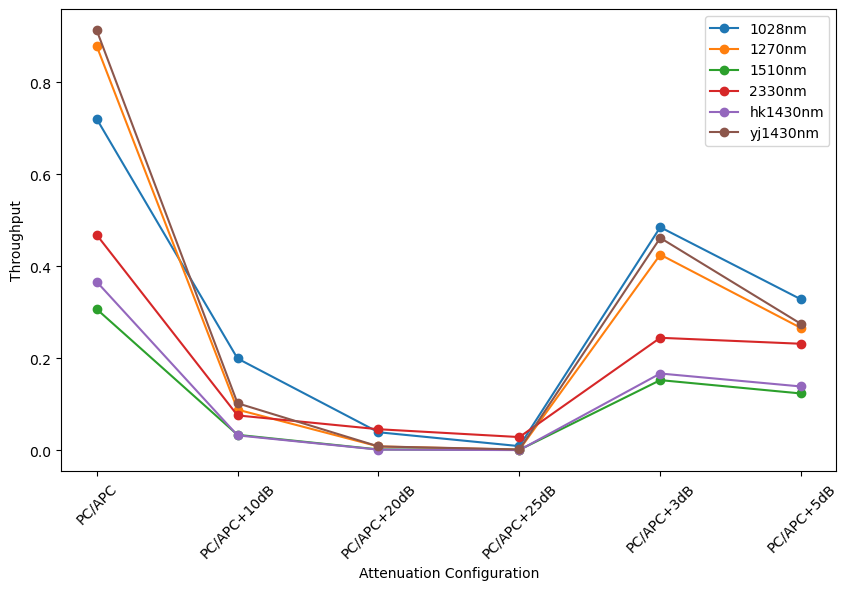

In [17]:
mean_powers = attenuation_df.groupby(['laser', 'dut'])[['power', 'current']].mean().reset_index()

plt.figure(figsize=(10, 6))
for laser in mean_powers['laser'].unique():
    laser_data = mean_powers[mean_powers['laser'] == laser]
    plt.plot(laser_data['dut'], laser_data['power']/laser_data['current'], 'o-', label=f'{laser}nm')

plt.xticks(rotation=45)
plt.xlabel('Attenuation Configuration')
plt.ylabel('Throughput')
plt.legend()